# Linkage Synthesis: Hybrid GA + Two-Objective Gradient Search

This streamlined notebook keeps the advanced starter's mixed-variable mechanism search. After every NSGA-II generation, each mechanism creates two local-search candidates: one distance-gradient step and one material-gradient step. NSGA-II then selects the next population from the GA population plus both gradient branches.


In [1]:
# Run once in a fresh Colab/session.
%%capture
!git clone https://github.com/decode-mit/2.156-CP1-2026.git
!mv ./2.156-CP1-2026/* .
!rm -rf ./2.156-CP1-2026
!pip install pymoo==0.6.1 svgpath2mpl


In [2]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

import copy
import random
import numpy as np
import matplotlib.pyplot as plt

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.mixed import (
    MixedVariableDuplicateElimination,
    MixedVariableMating,
)
from pymoo.core.population import Population
from pymoo.core.problem import ElementwiseProblem
from pymoo.core.sampling import Sampling
from pymoo.core.variable import Binary, Integer, Real
from pymoo.optimize import minimize

from LINKS.CP import REFERENCE_POINTS, evaluate_submission, make_empty_submission
from LINKS.Geometry import CurveEngine
from LINKS.Kinematics import MechanismSolver
from LINKS.Optimization import DifferentiableTools, MechanismRandomizer, Tools
from LINKS.Visualization import MechanismVisualizer

SEED = 123
np.random.seed(SEED)
random.seed(SEED)


## Configuration

Set `TARGETS_TO_RUN` to `[0, 1, 2]` for a complete submission. The default runs one target so the notebook can be tested quickly.


In [15]:
target_curves = np.load("kangaroo_target_curves.npy")

TARGET_NAMES = [
    "Kangaroo 1 (round body)",
    "Kangaroo 2 (no ears, no tail)",
    "Kangaroo 3 (full meme)",
]

TARGETS_TO_RUN = [0,1,2]       # Change to [0, 1, 2] for all three problems.
N_JOINTS = 7
POPULATION_SIZE = 100
N_GENERATIONS = 100

# One branch descends each objective after every GA generation.
DISTANCE_STEP_SIZE = 4e-3
MATERIAL_STEP_SIZE = 4e-3
MAX_GRADIENT_NORM = 100.0  # Guards against near-locking gradient explosions.

for i in TARGETS_TO_RUN:
    print(TARGET_NAMES[i], "reference point:", REFERENCE_POINTS[i])


Kangaroo 1 (round body) reference point: [ 0.75 10.  ]
Kangaroo 2 (no ears, no tail) reference point: [ 1.2 10. ]
Kangaroo 3 (full meme) reference point: [ 1.75 20.  ]


## Mixed-variable mechanism problem


In [16]:
PROBLEM_TOOLS = Tools(device="cpu")
PROBLEM_TOOLS.compile()


class MechanismSynthesisProblem(ElementwiseProblem):
    def __init__(self, target_curve, n_joints, reference_point):
        self.N = n_joints
        variables = {}

        for i in range(n_joints):
            for j in range(i):
                variables[f"C{j}_{i}"] = Binary()
        del variables["C0_1"]  # Motor link is always present.

        for i in range(2 * n_joints):
            variables[f"X0{i}"] = Real(bounds=(0.0, 1.0))
        for i in range(n_joints):
            variables[f"fixed_nodes{i}"] = Binary()
        variables["target"] = Integer(bounds=(1, n_joints - 1))

        super().__init__(vars=variables, n_obj=2, n_constr=2)
        self.target_curve = np.asarray(target_curve)
        self.reference_point = np.asarray(reference_point)

    def convert_1D_to_mech(self, encoded):
        C = np.zeros((self.N, self.N), dtype=bool)
        C[0, 1] = True
        for i in range(self.N):
            for j in range(i):
                if (j, i) != (0, 1):
                    C[j, i] = bool(encoded[f"C{j}_{i}"])

        x0 = np.array([encoded[f"X0{i}"] for i in range(2 * self.N)]).reshape(self.N, 2)
        edges = np.argwhere(C)
        fixed_joints = np.flatnonzero(
            [encoded[f"fixed_nodes{i}"] for i in range(self.N)]
        ).astype(int)
        motor = np.array([0, 1])
        target_idx = int(encoded["target"])
        return x0, edges, fixed_joints, motor, target_idx

    def convert_mech_to_1D(self, x0, edges, fixed_joints, target_idx=None, **_):
        encoded = {"target": int(self.N - 1 if target_idx is None else target_idx)}
        C = np.zeros((self.N, self.N), dtype=bool)
        edges = np.asarray(edges, dtype=int)
        C[edges[:, 0], edges[:, 1]] = True
        C[edges[:, 1], edges[:, 0]] = True

        for i in range(self.N):
            for j in range(i):
                if (j, i) != (0, 1):
                    encoded[f"C{j}_{i}"] = bool(C[j, i])

        x0 = np.asarray(x0)
        if len(x0) < self.N:
            x0 = np.pad(x0, ((0, self.N - len(x0)), (0, 0)))
        for i, value in enumerate(x0[:self.N].ravel()):
            encoded[f"X0{i}"] = float(value)
        for i in range(self.N):
            encoded[f"fixed_nodes{i}"] = bool(i in fixed_joints)
        return encoded

    def _evaluate(self, encoded, out, *args, **kwargs):
        x0, edges, fixed_joints, motor, target_idx = self.convert_1D_to_mech(encoded)
        distance, material = PROBLEM_TOOLS(
            x0, edges, fixed_joints, motor, self.target_curve, target_idx=target_idx
        )
        out["F"] = np.array([distance, material], dtype=float)
        out["G"] = out["F"] - self.reference_point


## Random valid-mechanism initialization


In [17]:
class MechanismSampling(Sampling):
    def __init__(self, problem, population_size, seed):
        super().__init__()
        np.random.seed(seed)
        random.seed(seed)
        randomizer = MechanismRandomizer(
            min_size=problem.N, max_size=problem.N, device="cpu"
        )
        self.samples = [
            problem.convert_mech_to_1D(**randomizer(n=problem.N))
            for _ in range(population_size)
        ]

    def _do(self, problem, n_samples, **kwargs):
        return np.array(
            [copy.deepcopy(self.samples[i % len(self.samples)]) for i in range(n_samples)],
            dtype=object,
        )


## NSGA-II with distance and material gradient branches

Only continuous joint coordinates are changed by the gradient steps. Connectivity, fixed-joint flags, motor, and target-joint choice remain under GA control.


In [18]:
GRADIENT_TOOLS = DifferentiableTools(device="cpu")
GRADIENT_TOOLS.compile()


class DualGradientNSGA2(NSGA2):
    def __init__(
        self,
        *args,
        distance_step_size=4e-4,
        material_step_size=4e-4,
        max_gradient_norm=100.0,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)
        self.distance_step_size = distance_step_size
        self.material_step_size = material_step_size
        self.max_gradient_norm = max_gradient_norm
        self.gradient_candidates_per_generation = []

    def _initialize_advance(self, infills=None, **kwargs):
        # Pymoo counts the evaluated initial population as generation 1.
        # Refine it too, so every reported generation gets both gradient branches.
        super()._initialize_advance(infills=infills, **kwargs)
        self._dual_gradient_refinement(**kwargs)

    def _advance(self, infills=None, **kwargs):
        # First complete the normal GA generation (mating, evaluation, survival).
        super()._advance(infills=infills, **kwargs)
        # Then inject one distance-descent and one material-descent candidate
        # per population member and run NSGA-II survival again.
        self._dual_gradient_refinement(**kwargs)

    def _bounded_step(self, x0, gradient, step_size):
        gradient = np.asarray(gradient, dtype=float)
        if gradient.shape != x0.shape or not np.all(np.isfinite(gradient)):
            return None
        norm = np.linalg.norm(gradient)
        if not np.isfinite(norm) or norm == 0:
            return None
        if norm > self.max_gradient_norm:
            gradient = gradient * (self.max_gradient_norm / norm)
        return np.clip(x0 - step_size * gradient, 0.0, 1.0)

    def _dual_gradient_refinement(self, **kwargs):
        encoded_population = self.pop.get("X")
        decoded = [self.problem.convert_1D_to_mech(x) for x in encoded_population]
        x0s = [m[0] for m in decoded]
        edges = [m[1] for m in decoded]
        fixed_joints = [m[2] for m in decoded]
        motors = [m[3] for m in decoded]
        target_idxs = [m[4] for m in decoded]

        _, _, distance_grads, material_grads = GRADIENT_TOOLS(
            x0s,
            edges,
            fixed_joints,
            motors,
            self.problem.target_curve,
            target_idxs,
        )

        refined = []
        for encoded, mech, distance_grad, material_grad in zip(
            encoded_population, decoded, distance_grads, material_grads
        ):
            x0, edges_i, fixed_i, _, target_i = mech
            for gradient, step_size in (
                (distance_grad, self.distance_step_size),
                (material_grad, self.material_step_size),
            ):
                new_x0 = self._bounded_step(x0, gradient, step_size)
                if new_x0 is not None:
                    candidate = copy.deepcopy(encoded)
                    for j, value in enumerate(new_x0.ravel()):
                        candidate[f"X0{j}"] = float(value)
                    refined.append(candidate)

        self.gradient_candidates_per_generation.append(len(refined))
        if not refined:
            return

        gradient_pop = Population.new("X", np.array(refined, dtype=object))
        self.evaluator.eval(self.problem, gradient_pop, algorithm=self)
        combined = Population.merge(self.pop, gradient_pop)
        self.pop = self.survival.do(
            self.problem,
            combined,
            n_survive=self.pop_size,
            algorithm=self,
            **kwargs,
        )


## Run optimization


In [19]:
def run_target(target_index, seed=SEED):
    problem = MechanismSynthesisProblem(
        target_curve=target_curves[target_index],
        n_joints=N_JOINTS,
        reference_point=REFERENCE_POINTS[target_index],
    )
    algorithm = DualGradientNSGA2(
        pop_size=POPULATION_SIZE,
        sampling=MechanismSampling(problem, POPULATION_SIZE, seed),
        mating=MixedVariableMating(
            eliminate_duplicates=MixedVariableDuplicateElimination()
        ),
        eliminate_duplicates=MixedVariableDuplicateElimination(),
        distance_step_size=DISTANCE_STEP_SIZE,
        material_step_size=MATERIAL_STEP_SIZE,
        max_gradient_norm=MAX_GRADIENT_NORM,
    )
    result = minimize(
        problem,
        algorithm,
        ("n_gen", N_GENERATIONS),
        seed=seed,
        verbose=True,
        save_history=False,
    )
    return problem, result


runs = {}
for target_index in TARGETS_TO_RUN:
    print(f"\nRunning Problem {target_index + 1}: {TARGET_NAMES[target_index]}")
    runs[target_index] = run_target(target_index, seed=SEED + target_index)



Running Problem 1: Kangaroo 1 (round body)
n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      299 |      1 |  0.0532289147 |  2.9147383791 |             - |             -
     2 |      599 |      1 |  0.0153167844 |  1.7207109487 |             - |             -
     3 |      899 |      1 |  0.000000E+00 |  0.6240054131 |             - |             -
     4 |     1199 |      3 |  0.000000E+00 |  0.2459649920 |  1.0095199015 |         ideal
     5 |     1499 |      1 |  0.000000E+00 |  0.1093166333 |  0.3355336189 |         ideal
     6 |     1799 |      6 |  0.000000E+00 |  0.0435578448 |  0.9566137129 |         ideal
     7 |     2099 |     21 |  0.000000E+00 |  0.000000E+00 |  0.0387981967 |             f
     8 |     2399 |     23 |  0.000000E+00 |  0.000000E+00 |  0.5876016517 |         ideal
     9 |     2699 |      4 |  0.000000E+00 |  0.000000E+00 |  0.8393855107 |         ideal
    10 |     2999 |      7 |  0.000000E+00 |  

## Inspect the Pareto front and endpoint mechanisms


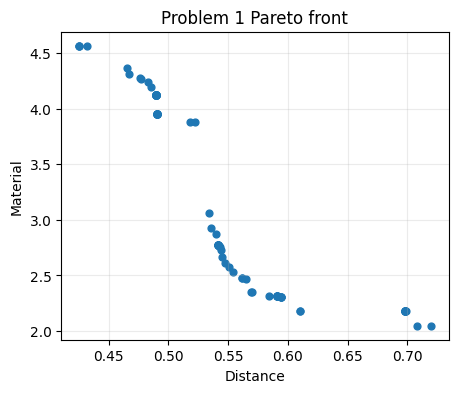

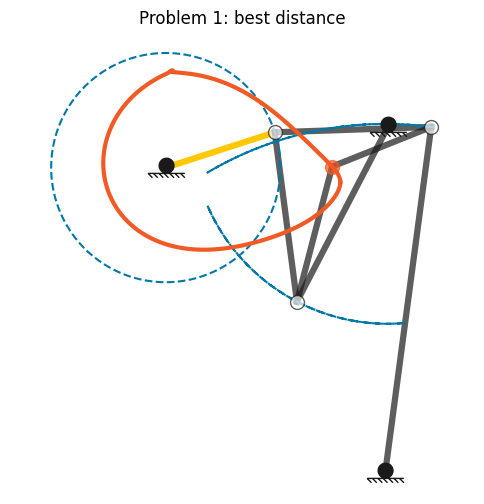

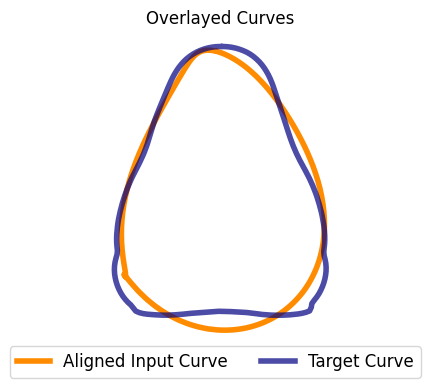

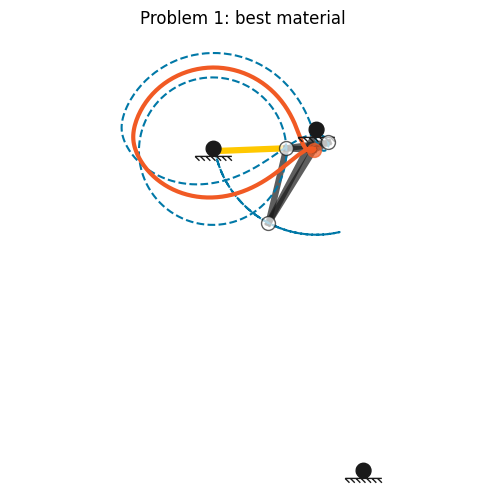

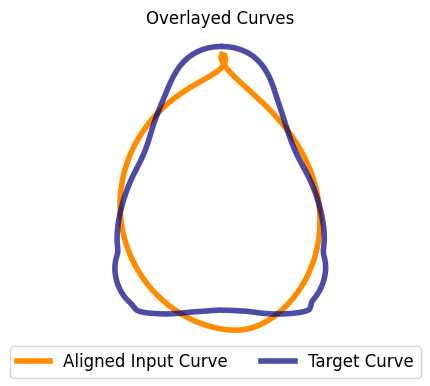

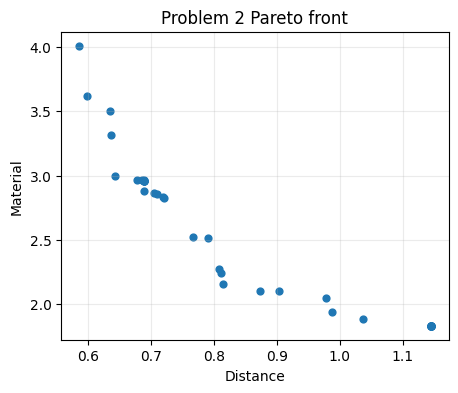

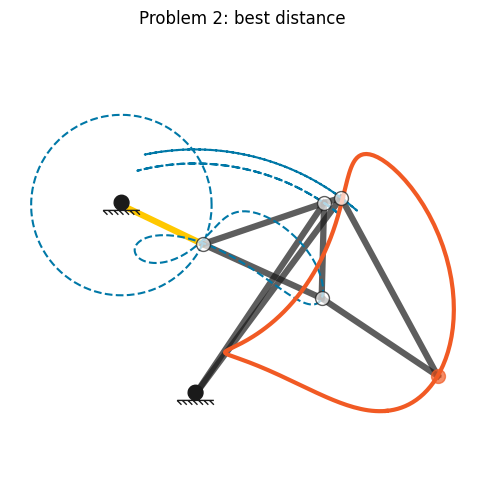

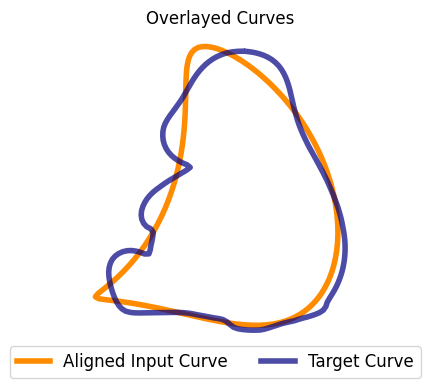

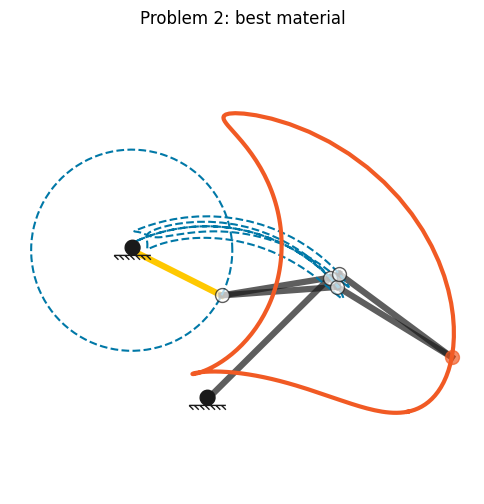

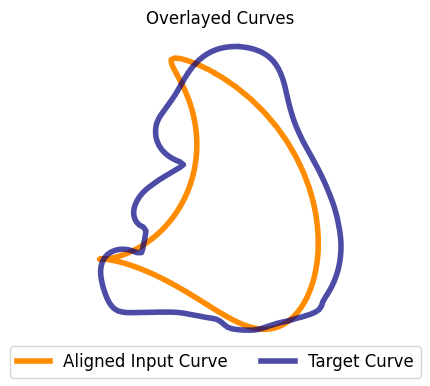

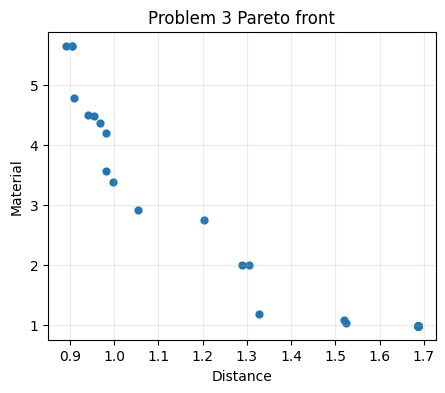

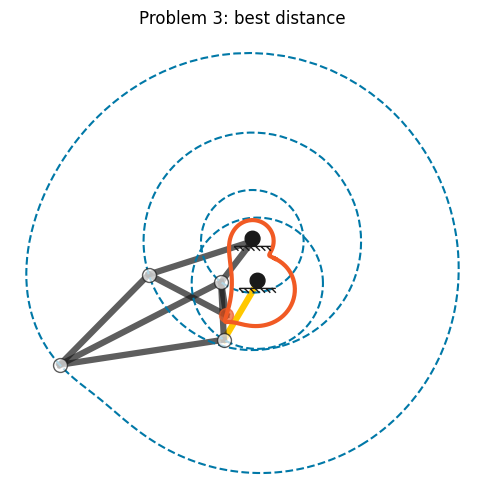

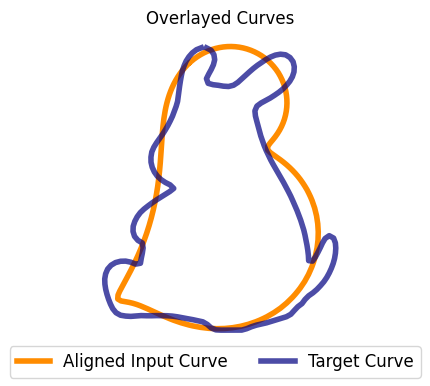

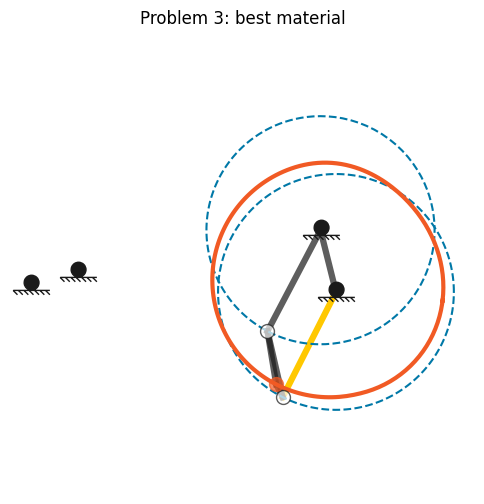

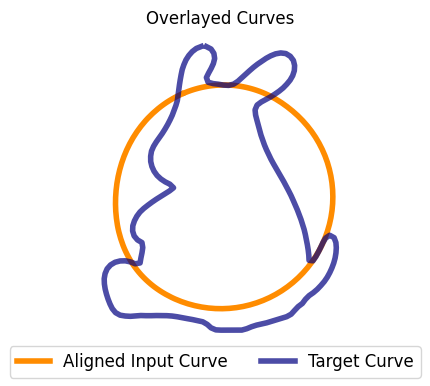

In [20]:
visualizer = MechanismVisualizer()
solver = MechanismSolver(device="cpu")
curve_engine = CurveEngine(device="cpu")


def result_members(result):
    if result.X is None:
        return []
    return [result.X] if isinstance(result.X, dict) else list(result.X)


for target_index, (problem, result) in runs.items():
    members = result_members(result)
    if not members:
        print(f"Problem {target_index + 1}: no feasible solution found")
        continue

    F = np.atleast_2d(result.F)
    plt.figure(figsize=(5, 4))
    plt.scatter(F[:, 0], F[:, 1], s=24)
    plt.xlabel("Distance")
    plt.ylabel("Material")
    plt.title(f"Problem {target_index + 1} Pareto front")
    plt.grid(alpha=0.25)
    plt.show()

    for label, objective in (("distance", 0), ("material", 1)):
        encoded = members[int(np.argmin(F[:, objective]))]
        x0, edges, fixed, motor, target_joint = problem.convert_1D_to_mech(encoded)
        fig, ax = plt.subplots(figsize=(6, 6))
        visualizer(x0, edges, fixed, motor, highlight=target_joint, ax=ax)
        ax.set_title(f"Problem {target_index + 1}: best {label}")
        plt.show()
        traced_curve = solver(x0, edges, fixed, motor)[target_joint]
        curve_engine.visualize_comparison(traced_curve, target_curves[target_index])


## Build and save the submission

If only one target was run, the other submission lists remain empty. Run all three targets before submitting to the leaderboard.


In [21]:
submission = make_empty_submission()

for target_index, (problem, result) in runs.items():
    for encoded in result_members(result):
        x0, edges, fixed_joints, motor, target_joint = problem.convert_1D_to_mech(encoded)
        submission[f"Problem {target_index + 1}"].append(
            {
                "x0": x0,
                "edges": edges,
                "fixed_joints": fixed_joints,
                "motor": motor,
                "target_joint": target_joint,
            }
        )

np.save("hybrid_ga_gradient_submission.npy", submission)
evaluate_submission(submission)


{'Overall Score': 1.9346494966046404,
 'Score Breakdown': {'Problem 1': 2.3003790085868587,
  'Problem 2': 4.68661513641164,
  'Problem 3': 15.293488945793975},
 'Normalized Score Breakdown': {'Problem 1': 1.1501895042934294,
  'Problem 2': 3.1244100909410935,
  'Problem 3': 1.5293488945793974}}


Problem 1
Submission index: 37
Joint count: 7
Target joint: 6
Distance: 0.708412
Material: 2.049669
Normalized objectives: [0.94454932 0.2049669 ]
Marginal hypervolume contribution: 0.001481


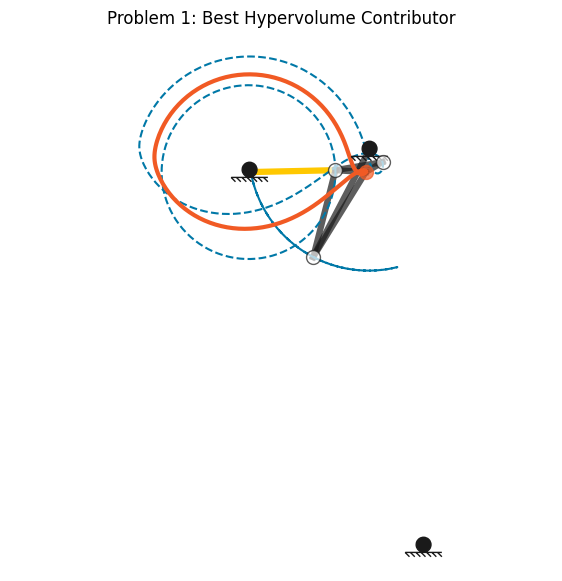


Problem 2
Submission index: 0
Joint count: 7
Target joint: 6
Distance: 0.585936
Material: 4.008912
Normalized objectives: [0.48827971 0.40089121]
Marginal hypervolume contribution: 0.074130


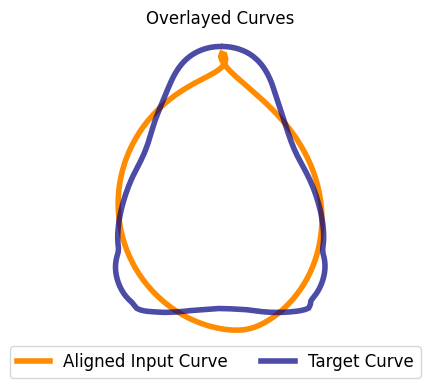

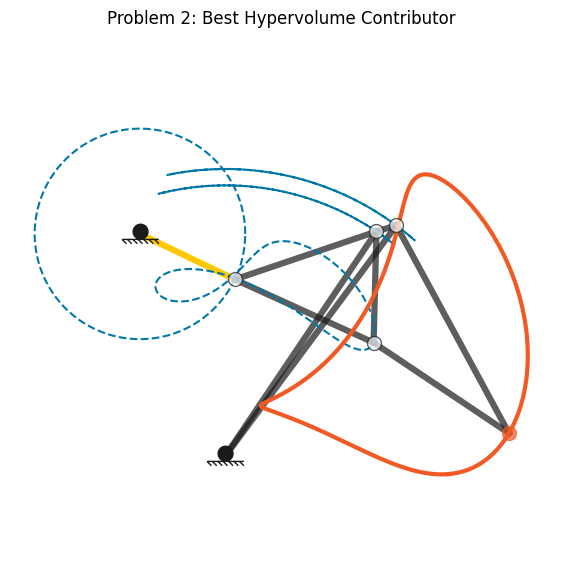


Problem 3
Submission index: 3
Joint count: 7
Target joint: 6
Distance: 0.890544
Material: 5.648824
Normalized objectives: [0.50888242 0.28244119]
Marginal hypervolume contribution: 0.195016


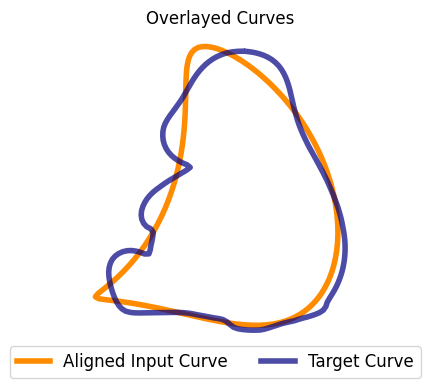

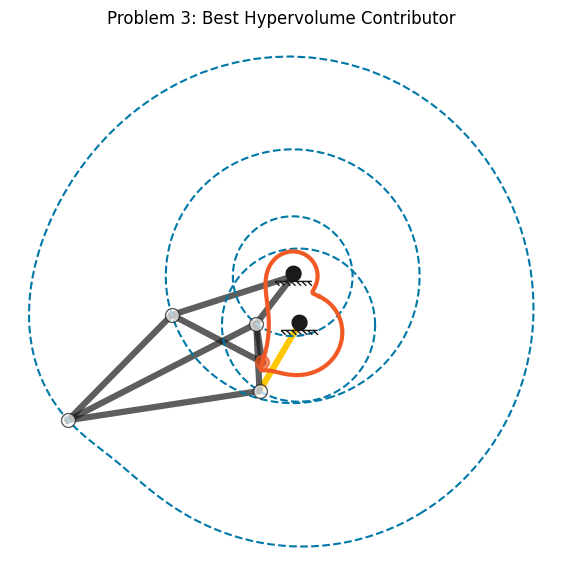

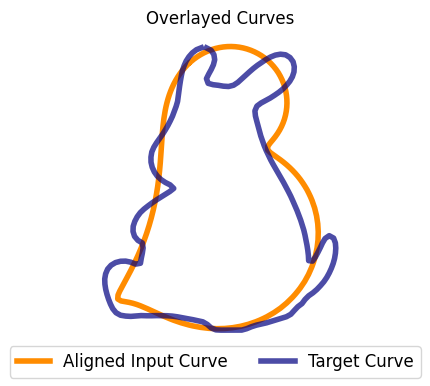

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from pymoo.indicators.hv import HV
from LINKS.CP import REFERENCE_POINTS
from LINKS.Kinematics import MechanismSolver
from LINKS.Optimization import Tools
from LINKS.Visualization import MechanismVisualizer
from LINKS.Geometry import CurveEngine


# ============================================================
# FILE TO VISUALIZE
# ============================================================

SUBMISSION_FILE = "hybrid_ga_gradient_submission.npy"


# ============================================================
# LOAD SUBMISSION AND CREATE TOOLS
# ============================================================

submission = np.load(
    SUBMISSION_FILE,
    allow_pickle=True,
).item()

score_tools = Tools(device="cpu")
score_tools.compile()

solver = MechanismSolver(device="cpu")
visualizer = MechanismVisualizer()
curve_engine = CurveEngine(device="cpu")


# ============================================================
# EVALUATE EVERY MECHANISM
# ============================================================

def evaluate_mechanism(mechanism, target_index):
    target_joint = mechanism.get(
        "target_joint",
        mechanism.get("target_idx"),
    )

    distance, material = score_tools(
        mechanism["x0"],
        mechanism["edges"],
        mechanism["fixed_joints"],
        mechanism["motor"],
        target_curves[target_index],
        target_idx=target_joint,
    )

    return np.array(
        [float(distance), float(material)],
        dtype=float,
    )


def find_best_hypervolume_contributor(mechanisms, target_index):
    reference_point = np.asarray(
        REFERENCE_POINTS[target_index],
        dtype=float,
    )

    objective_values = np.array(
        [
            evaluate_mechanism(mechanism, target_index)
            for mechanism in mechanisms
        ]
    )

    feasible = (
        np.all(np.isfinite(objective_values), axis=1)
        & np.all(objective_values <= reference_point, axis=1)
    )

    feasible_indices = np.flatnonzero(feasible)

    if len(feasible_indices) == 0:
        print(
            f"Problem {target_index + 1}: "
            "no feasible mechanisms; selecting the closest one."
        )

        normalized = objective_values / reference_point
        selected_index = int(
            np.argmin(np.linalg.norm(normalized, axis=1))
        )

        return selected_index, objective_values, 0.0

    feasible_F = objective_values[feasible_indices]
    indicator = HV(ref_point=reference_point)
    full_hypervolume = float(indicator(feasible_F))

    contributions = []

    for local_index in range(len(feasible_F)):
        remaining_F = np.delete(
            feasible_F,
            local_index,
            axis=0,
        )

        remaining_hypervolume = (
            float(indicator(remaining_F))
            if len(remaining_F) > 0
            else 0.0
        )

        contributions.append(
            full_hypervolume - remaining_hypervolume
        )

    best_local_index = int(np.argmax(contributions))
    selected_index = int(
        feasible_indices[best_local_index]
    )

    return (
        selected_index,
        objective_values,
        contributions[best_local_index],
    )


# ============================================================
# SELECT AND VISUALIZE THE BEST MECHANISM FOR EACH PROBLEM
# ============================================================

for target_index in range(3):
    problem_name = f"Problem {target_index + 1}"
    mechanisms = submission.get(problem_name, [])

    if len(mechanisms) == 0:
        print(f"{problem_name}: no mechanisms in submission")
        continue

    (
        best_index,
        all_objectives,
        hv_contribution,
    ) = find_best_hypervolume_contributor(
        mechanisms,
        target_index,
    )

    best = mechanisms[best_index]
    best_F = all_objectives[best_index]
    reference_point = np.asarray(
        REFERENCE_POINTS[target_index]
    )

    target_joint = best.get(
        "target_joint",
        best.get("target_idx"),
    )

    print("\n" + "=" * 60)
    print(problem_name)
    print("=" * 60)
    print(f"Submission index: {best_index}")
    print(f"Joint count: {len(best['x0'])}")
    print(f"Target joint: {target_joint}")
    print(f"Distance: {best_F[0]:.6f}")
    print(f"Material: {best_F[1]:.6f}")
    print(
        "Normalized objectives:",
        best_F / reference_point,
    )
    print(
        "Marginal hypervolume contribution:",
        f"{hv_contribution:.6f}",
    )

    # Plot the mechanism.
    fig, ax = plt.subplots(figsize=(7, 7))

    visualizer(
        best["x0"],
        best["edges"],
        best["fixed_joints"],
        best["motor"],
        highlight=target_joint,
        ax=ax,
    )

    ax.set_title(
        f"{problem_name}: Best Hypervolume Contributor"
    )
    plt.show()

    # Generate the traced curve.
    trajectories = solver(
        best["x0"],
        best["edges"],
        best["fixed_joints"],
        best["motor"],
    )

    generated_curve = trajectories[target_joint]

    # Compare generated and target curves.
    curve_engine.visualize_comparison(
        generated_curve,
        target_curves[target_index],
    )